<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/08_lisa_wdm_time_frequency.ipynb)

# Part 3D: LISA WDM time-frequency analysis

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**


## Goal and route

Use a Wilson--Daubechies--Meyer (WDM) time-frequency representation to see where gaps and changing noise enter an analysis.

> **💡 Live route**
>
> Run the gap and non-stationarity laboratory, then complete its local question. The masked WDM global-fit counterpart is a read-later extension.


**Boundary:** The diagonal WDM likelihood is exact only under its covariance assumptions. Gaps and non-stationarity can correlate pixels.

In [1]:
import os, sys, subprocess, importlib.util

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
needed = ("lisatools", "gpubackendtools", "jaxgb", "eryn", "wdm_transform")
if any(importlib.util.find_spec(package) is None for package in needed):
    if IN_COLAB:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "lisaanalysistools==1.2.5",
                "gpubackendtools==0.1.1",
                "jaxgb==0.2.1",
                "astropy==7.2.0",
                "eryn==1.2.6",
                "wdm-transform==0.5.0",
            ]
        )
    else:
        raise ImportError("Install the pinned LISA requirements, or run in Colab.")

In [2]:
import itertools
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config

config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="IProgress not found.*")
from lisatools.sensitivity import (
    A1TDISens,
    E1TDISens,
    SensitivityMatrix,
    get_sensitivity,
)
from lisatools.utils.constants import YRSID_SI
from lisaorbits import EqualArmlengthOrbits, KeplerianOrbits, LINKS
from lisaorbits.utils import emitter, receiver
from lisaconstants import c as C_SI
from jaxgb.jaxgb import JaxGB
from jaxgb.params import GBObject
from wdm_transform import (
    TimeSeries as WDMTimeSeries,
    WDM,
    wdm_inner_product,
    wdm_noise_variance,
)

rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")


def show_animation(animation):
    # H.264 video: ~40x smaller in the notebook than one PNG per frame
    try:
        return display(HTML(animation.to_html5_video()))
    except RuntimeError:  # ffmpeg unavailable: fall back to per-frame PNGs
        return display(HTML(animation.to_jshtml()))

## 1. Real LISA data will be more complicated

| Complication | What students should ask | Analysis consequence |
| --- | --- | --- |
| data gaps and irregular availability | why is data missing; is the gap informative? | Fourier bins become coupled; windowing/inpainting/gap-aware likelihoods |
| time-varying instrument noise | is one mission-long PSD meaningful? | segmented, time-frequency, or explicitly non-stationary noise models |
| changing Galactic foreground | which binaries become resolvable with time? | foreground and catalogue must be inferred together |
| moving/breathing constellation | are delays and orbits known accurately enough? | time-dependent link response and TDI generation |
| glitches, clock/laser artefacts, calibration | can an instrumental transient mimic a source? | extra nuisance models, vetoes, robust likelihoods |
| overlapping source classes | what belongs to the residual? | global rather than source-by-source inference |
| unknown catalogue size | how many binaries are present? | trans-dimensional/RJ methods and label-switching care |

The following lightweight laboratory is intentionally editable. Change the
gap, drift, and noise-growth parameters and rerun it. Throughout this notebook,
a grey hatched span means **time that is unavailable to the analysis**; it is a
plot annotation, not a measured value.

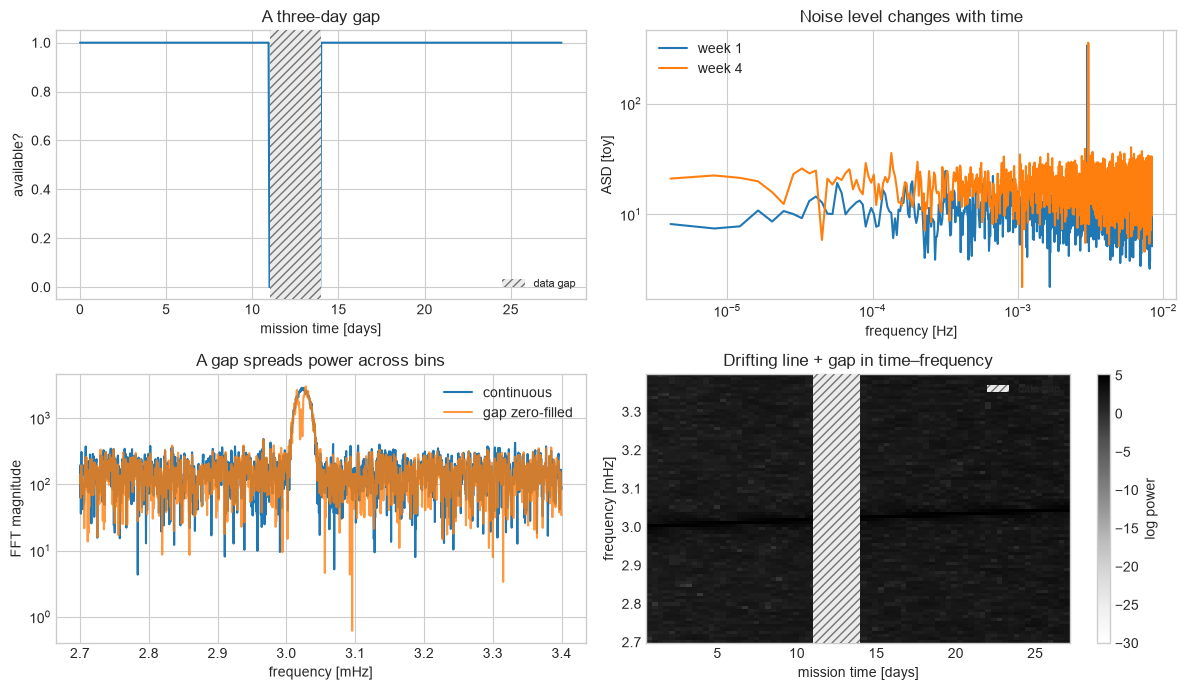

In [3]:
from scipy.signal import welch, spectrogram

# Student playground: all three controls are deliberately visible.
GAP_DAYS = (11, 14)
FREQUENCY_DRIFT = 2e-11
NOISE_GROWTH = 0.9
cadence = 60.0
mission_days = 28.0
toy_time = np.arange(0, mission_days * 86400, cadence)
sample_rate_toy = 1 / cadence
noise_scale = 1 + NOISE_GROWTH * toy_time / toy_time[-1]
phase = 2 * np.pi * (3e-3 * toy_time + 0.5 * FREQUENCY_DRIFT * toy_time**2)
continuous_data = noise_scale * rng.normal(size=toy_time.size) + 1.5 * np.sin(phase)
available = ~((toy_time >= GAP_DAYS[0] * 86400) & (toy_time < GAP_DAYS[1] * 86400))
gapped_data = continuous_data.copy()
gapped_data[~available] = 0  # zero fill only to expose leakage below

# One visual language for missing time everywhere in this notebook. Keep the
# plotted values masked/zero-filled as required by the demonstration, then draw
# an opaque hatched overlay so blank pixels can never be mistaken for zero
# power, clipping, or a rendering failure.
GAP_HATCH_STYLE = dict(
    facecolor="0.92",
    edgecolor="0.45",
    hatch="////",
    linewidth=0.0,
    alpha=1.0,
    zorder=20,
)


def mark_gap(axis, start=GAP_DAYS[0], end=GAP_DAYS[1], label="data gap"):
    return axis.axvspan(start, end, label=label, **GAP_HATCH_STYLE)


early = continuous_data[toy_time < 7 * 86400]
late = continuous_data[toy_time > 21 * 86400]
f_early, p_early = welch(early, fs=sample_rate_toy, nperseg=4096)
f_late, p_late = welch(late, fs=sample_rate_toy, nperseg=4096)
window = np.hanning(toy_time.size)
fft_frequency = np.fft.rfftfreq(toy_time.size, cadence)
fft_full = np.abs(np.fft.rfft(window * continuous_data))
fft_gap = np.abs(np.fft.rfft(window * gapped_data))
f_spec, t_spec, p_spec = spectrogram(
    gapped_data, fs=sample_rate_toy, nperseg=2048, noverlap=1536
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(toy_time[::80] / 86400, available[::80].astype(int))
axes[0, 0].set(
    xlabel="mission time [days]", ylabel="available?", title="A three-day gap"
)
mark_gap(axes[0, 0])
axes[0, 0].legend(fontsize=8, loc="lower right")
axes[0, 1].loglog(f_early[1:], np.sqrt(p_early[1:]), label="week 1")
axes[0, 1].loglog(f_late[1:], np.sqrt(p_late[1:]), label="week 4")
axes[0, 1].set(
    xlabel="frequency [Hz]", ylabel="ASD [toy]", title="Noise level changes with time"
)
axes[0, 1].legend()
near = (fft_frequency > 2.7e-3) & (fft_frequency < 3.4e-3)
axes[1, 0].semilogy(1e3 * fft_frequency[near], fft_full[near], label="continuous")
axes[1, 0].semilogy(
    1e3 * fft_frequency[near], fft_gap[near], label="gap zero-filled", alpha=0.8
)
axes[1, 0].set(
    xlabel="frequency [mHz]",
    ylabel="FFT magnitude",
    title="A gap spreads power across bins",
)
axes[1, 0].legend()
band = (f_spec > 2.7e-3) & (f_spec < 3.4e-3)
image = axes[1, 1].pcolormesh(
    t_spec / 86400, 1e3 * f_spec[band], np.log10(p_spec[band] + 1e-30), shading="auto"
)
mark_gap(axes[1, 1])
axes[1, 1].legend(fontsize=8, loc="upper right")
axes[1, 1].set(
    xlabel="mission time [days]",
    ylabel="frequency [mHz]",
    title="Drifting line + gap in time–frequency",
)
fig.colorbar(image, ax=axes[1, 1], label="log power")
fig.tight_layout()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-gap-laboratory.png" alt="expected output: lisa-gap-laboratory" style="max-width:100%">

</details>

### Wilson--Daubechies--Meyer (WDM) time--frequency map and likelihood

The Wilson--Daubechies--Meyer transform gives localised real coefficients $w_{nm}$ on a
time--frequency grid. For stationary Gaussian noise and a diagonal WDM
approximation,

$$
\log \mathcal L_{\rm WDM}=-\frac12\sum_{n,m}
\frac{(w^d_{nm}-w^h_{nm})^2}{\sigma_{nm}^2}+\mathrm{constant},
\qquad
\sigma_{nm}^2=\frac{N\,S(f_m)}{2\,\Delta t}.
$$

This is the WDM counterpart of the diagonal frequency-domain Whittle
likelihood. It is useful because the map makes a drifting signal, changing
noise, and a gap visible. It is not magically exact: a gap and non-stationary
noise correlate pixels, so the diagonal form below is a controlled teaching
approximation.

WDM grid: 280 time pixels x 145 frequency columns
Diagonal stationary-noise WDM log likelihood (up to a constant): -43218.1


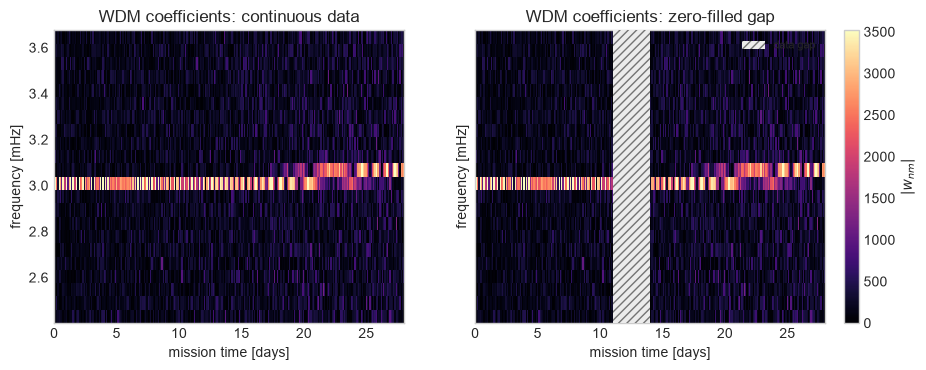

pixel size: 2.40 h x 0.058 mHz
line drift over the mission: 0.048 mHz
Raise FREQUENCY_DRIFT until the drift exceeds one pixel and the track tilts.


In [4]:
toy_signal = 1.5 * np.sin(phase)
WDM_NT = 280  # 28 days at 60 s cadence gives an exactly rectangular 280 x 144 grid.
wdm_data = WDM.from_time_series(WDMTimeSeries(continuous_data, dt=cadence), nt=WDM_NT)
wdm_gap = WDM.from_time_series(WDMTimeSeries(gapped_data, dt=cadence), nt=WDM_NT)
wdm_model = WDM.from_time_series(WDMTimeSeries(toy_signal, dt=cadence), nt=WDM_NT)
wdm_coeffs = np.asarray(wdm_data.coeffs[0])
wdm_gap_coeffs = np.asarray(wdm_gap.coeffs[0])
wdm_model_coeffs = np.asarray(wdm_model.coeffs[0])
wdm_nf = wdm_coeffs.shape[1] - 1
# Use the transform's own grid: the row spacing is nyquist/nf = 1/(2*nf*dt),
# not 1/(nf*dt).  Building it by hand is off by a factor of two.
wdm_frequency = np.asarray(wdm_data.freq_grid)
# Unit-variance sampled white noise has one-sided PSD 2*dt.  We deliberately use
# this stationary reference even though the toy noise grows with time.
wdm_stationary_var = wdm_noise_variance(
    np.full(wdm_nf + 1, 2 * cadence), nt=WDM_NT, nf=wdm_nf, dt=cadence
)
wdm_residual = wdm_coeffs - wdm_model_coeffs
logL_wdm = -0.5 * wdm_inner_product(wdm_residual, wdm_residual, wdm_stationary_var)
print(f"WDM grid: {WDM_NT} time pixels x {wdm_nf+1} frequency columns")
print(
    f"Diagonal stationary-noise WDM log likelihood (up to a constant): {logL_wdm:.1f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
show = (wdm_frequency > 2.4e-3) & (wdm_frequency < 3.7e-3)
pixel_time = np.linspace(0, mission_days, WDM_NT)
# One shared colour scale, or the two panels cannot be compared by eye.
scale = np.percentile(np.abs(wdm_coeffs[:, show]), 99.5)
for ax, coeffs, title in zip(
    axes, (wdm_coeffs, wdm_gap_coeffs), ("continuous data", "zero-filled gap")
):
    image = ax.pcolormesh(
        pixel_time,
        1e3 * wdm_frequency[show],
        np.abs(coeffs[:, show].T),
        shading="nearest",
        cmap="magma",
        vmin=0,
        vmax=scale,
    )
    ax.set(
        xlabel="mission time [days]",
        ylabel="frequency [mHz]",
        title=f"WDM coefficients: {title}",
    )
mark_gap(axes[1])
axes[1].legend(fontsize=8, loc="upper right")
fig.colorbar(image, ax=axes, label=r"$|w_{nm}|$", pad=0.02)
plt.show()

print(f"pixel size: {wdm_data.delta_t/3600:.2f} h x {wdm_data.delta_f*1e3:.3f} mHz")
print(f"line drift over the mission: {FREQUENCY_DRIFT*toy_time[-1]*1e3:.3f} mHz")
print("Raise FREQUENCY_DRIFT until the drift exceeds one pixel and the track tilts.")

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-wdm-map.png" alt="expected output: lisa-wdm-map" style="max-width:100%">

</details>

### Frequency domain versus WDM: the same inner product

Before trusting the wavelet picture, check that it is the *same analysis*. Both
domains compute one number, the noise-weighted inner product, and an orthogonal
change of basis must leave it unchanged:

$$
(h\mid h)_{\rm freq}=4\Delta f\sum_k\frac{|\tilde h_k|^2}{S(f_k)}
\qquad\text{versus}\qquad
(h\mid h)_{\rm WDM}=\sum_{n,m}\frac{w_{nm}^2}{\sigma_{nm}^2}.
$$

If those disagree, the wavelet normalisation is wrong and nothing built on top
of it can be believed. They should agree to several decimal places.

In [5]:
from wdm_transform import matched_filter_snr_rfft, matched_filter_snr_wdm

# A clean, gap-free signal in stationary white noise, so both domains are valid.
check_psd_value = 2 * cadence  # one-sided PSD of unit-variance sampled noise
check_frequency = np.fft.rfftfreq(toy_time.size, cadence)

snr_frequency_domain = matched_filter_snr_rfft(
    np.fft.rfft(toy_signal),
    np.full(check_frequency.size, check_psd_value),
    check_frequency,
    dt=cadence,
)
snr_wdm_domain = matched_filter_snr_wdm(wdm_model_coeffs, wdm_stationary_var)

print(f"optimal SNR, frequency domain : {snr_frequency_domain:.5f}")
print(f"optimal SNR, WDM domain       : {snr_wdm_domain:.5f}")
print(f"ratio                         : {snr_wdm_domain/snr_frequency_domain:.6f}")
print("\nSame signal, same noise model, two different bases.")

optimal SNR, frequency domain : 212.97695
optimal SNR, WDM domain       : 212.97695
ratio                         : 1.000000

Same signal, same noise model, two different bases.


### What the wavelet domain actually buys you

The two domains agree on clean, stationary data, so WDM is not a better
analysis in general. It earns its place when the *assumptions* behind the
frequency-domain likelihood fail, and both failures are on display in this
laboratory:

- **A gap is local in time, but every Fourier basis function is global.** One
  missing stretch therefore corrupts every frequency bin at once, which is the
  leakage seen earlier. In WDM the corruption is confined to the pixel columns
  that overlap the gap, so it can simply be **masked**.
- **Non-stationary noise is local in time too.** The frequency-domain Whittle
  likelihood has one $S(f)$ for the whole mission. In WDM the variance carries
  a time index, $\sigma_{nm}^2$, so a drifting noise level is just a
  column-dependent weight.

The next cell puts a number on the first point: recover the same injected
signal from gapped data, once by zero-filling in the frequency domain and once
by masking pixels in WDM.

In [6]:
gap_pixels = (pixel_time >= GAP_DAYS[0] - wdm_data.delta_t / 86400) & (
    pixel_time <= GAP_DAYS[1] + wdm_data.delta_t / 86400
)
masked_var = wdm_stationary_var.copy()
masked_var[gap_pixels, :] = np.nan  # NaN variance drops those pixels entirely


def recovered_snr(data_coeffs, variance):
    """Matched-filter SNR of the known template against the data."""
    numerator = wdm_inner_product(wdm_model_coeffs, data_coeffs, variance)
    normalisation = np.sqrt(
        wdm_inner_product(wdm_model_coeffs, wdm_model_coeffs, variance)
    )
    return numerator / normalisation


retained = available.mean()
print(f"data retained outside the gap : {retained:.3f}")
print(f"best achievable SNR           : {snr_frequency_domain*np.sqrt(retained):6.2f}")
print()
print(
    f"complete data                 : {recovered_snr(wdm_coeffs, wdm_stationary_var):6.2f}"
)
print(
    f"gap zero-filled, no mask      : {recovered_snr(wdm_gap_coeffs, wdm_stationary_var):6.2f}"
)
print(
    f"gap masked in WDM             : {recovered_snr(wdm_gap_coeffs, masked_var):6.2f}"
)
print(
    f"\nmasked pixel columns: {gap_pixels.sum()} of {WDM_NT}"
    f" = {gap_pixels.mean():.1%} of the mission"
)

data retained outside the gap : 0.893
best achievable SNR           : 201.24

complete data                 : 213.45
gap zero-filled, no mask      : 190.39
gap masked in WDM             : 200.93

masked pixel columns: 32 of 280 = 11.4% of the mission


### Tracking a noise level that changes

The likelihood above deliberately used one stationary variance even though the
toy noise grows by `NOISE_GROWTH` across the mission. In the frequency domain
fixing that means segmenting the data and re-estimating a PSD per segment. In
WDM the grid is *already* segmented: each pixel column is a short stretch of
time, so the noise level per column follows from the coefficients themselves.

Estimating it from off-signal frequency rows recovers the injected growth.

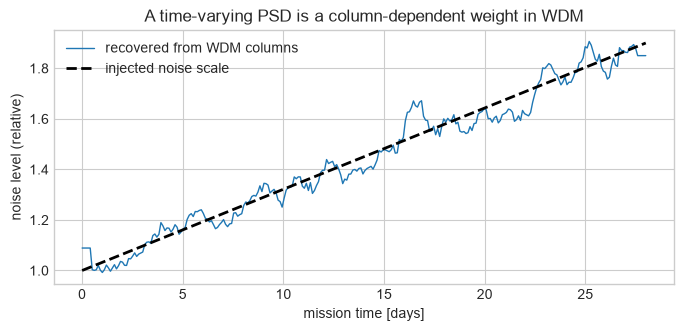

recovered growth across the mission : 0.882
injected NOISE_GROWTH               : 0.900


In [7]:
# Use every frequency row above the line, so the estimate is signal-free and
# averages enough pixels to be stable.
quiet_rows = (wdm_frequency > 3.8e-3) & (wdm_frequency < 8.0e-3)
column_variance = np.nanmean(wdm_coeffs[:, quiet_rows] ** 2, axis=1)
# Each column still averages only ~70 pixels, so smooth lightly over time.
smoothing = np.ones(9) / 9
column_variance = np.convolve(column_variance, smoothing, mode="same")
column_variance[:4] = column_variance[4]
column_variance[-4:] = column_variance[-5]
# Convert pixel variance back to a noise scale relative to the stationary value.
reference = np.nanmean(wdm_stationary_var[:, quiet_rows], axis=1)
recovered_scale = np.sqrt(column_variance / reference)

injected_scale = np.interp(pixel_time * 86400, toy_time, noise_scale)

fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(pixel_time, recovered_scale, lw=1, label="recovered from WDM columns")
ax.plot(pixel_time, injected_scale, "k--", lw=2, label="injected noise scale")
ax.set(
    xlabel="mission time [days]",
    ylabel="noise level (relative)",
    title="A time-varying PSD is a column-dependent weight in WDM",
)
ax.legend()
plt.show()

slope = np.polyfit(pixel_time, recovered_scale, 1)[0] * mission_days
print(f"recovered growth across the mission : {slope:.3f}")
print(f"injected NOISE_GROWTH               : {NOISE_GROWTH:.3f}")

**Where this stops being a teaching toy.** The diagonal WDM
likelihood is an approximation, not an identity. Masking whole pixel columns
throws away slightly more data than the gap itself, gap edges leave partially
contaminated pixels, and a real analysis must decide whether to mask, taper,
inpaint, or model the missing stretch, and propagate that choice into the
uncertainties. The resolution trade is also fixed by hand here: choosing `nt`
sets the pixel aspect ratio, and a signal drifting by less than one pixel
height looks stationary no matter which basis you use.

**Do not interpret zero-filling as the recommended gap treatment.** It is used here because its spectral leakage is immediately visible. A research analysis must define how gaps, edges, non-stationarity, and missing-data uncertainty enter the likelihood.

### Suggested investigations

- Set `GAP_DAYS=(0, 0)` and verify that the leakage pattern changes.
- Increase `FREQUENCY_DRIFT`; when does a stationary single-bin model fail?
- Fit the early PSD to late data. Which likelihood assumption is violated?
- Replace the hard gap with a taper and compare leakage against loss of usable data.
- Add a short glitch inside versus outside the gap.

### Question

A gap removes a small, contiguous stretch of time. Quantify how local it stays
in each representation.

1. What fraction of time samples is unavailable?
2. What fraction of WDM time columns sits directly over the gap?
3. Now estimate the Fourier-domain footprint: window the data with `available`
   and compare the periodogram with the ungapped one. Over how many frequency
   bins is the difference visible?

Two of those three numbers are small and one is not. Explain the odd one out.

In [8]:
# Your code here. `available`, `pixel_time`, and `GAP_DAYS` are defined above.

<details>
<summary>Hint</summary>

Multiplication by a gap window in time is a *convolution* in frequency, and
the window has sharp edges. WDM pixels keep their time location, so only the
columns over the gap are destroyed — though edge pixels are contaminated and
correlated with their neighbours.

</details>


> **📌 End of the live route**
>
> WDM does not make missing data harmless. It makes the affected time region
> visible and allows unaffected pixels to remain usable. The analysis must still
> define a mask or model for gap-edge pixels and propagate that decision into the
> likelihood.

## Extension: the global-fit residual in WDM pixels

Module 06 introduced residual handoff in the frequency domain. The following
controlled extension repeats the same fixed-shape amplitude problem using a
single gap mask in every source and noise update. Source coupling remains even
though the missing interval is localised.

### Controlled three-source counterpart

Nothing about blocked Gibbs sampling belongs specifically to a Fourier basis.
Module 06 used frequency-domain residuals. Here the data model is unchanged,

$$
d_{nm}=\sum_{i=1}^{3} a_i h^{(i)}_{nm}+n_{nm},
$$

but every datum, template, and residual is a WDM coefficient. The conditional
for amplitude $a_i$ uses the shared residual

$$
r^{(i)}_{nm}=d_{nm}-\sum_{j\ne i}a_jh^{(j)}_{nm},
$$

and the same Gaussian update as Module 06, with the **masked WDM inner
product** replacing the frequency-domain inner product. Columns in the gap and
a conservative edge guard have infinite uncertainty operationally: they are
excluded from every source and noise update.

This is a controlled counterpart to Module 06's fixed-shape example. The
source shapes and source count are known; only their amplitudes and a common
noise scale are inferred. The point is to expose residual handoff with missing
data, not to claim a production LISA global fit.

**Predict before running:** Does localising the gap in a handful of WDM
columns make the three overlapping sources independent of one another? What
information should the gap remove from every conditional update?

In [9]:
# Three nearly coincident binaries: visually they share one WDM ridge, but
# their phase evolution still lets the joint likelihood distinguish them.
WDM_GLOBAL_F0 = 3.0e-3 + np.array([0.0, 0.25e-6, 0.50e-6])
WDM_GLOBAL_PHASE = np.array([0.2, 0.5, 0.8])
WDM_GLOBAL_TRUTH = np.array([1.0, 0.75, 0.55])
WDM_GLOBAL_BASE_SNR = 30.0

wdm_global_time_templates = np.asarray(
    [
        np.sin(2 * np.pi * frequency * toy_time + phase0)
        for frequency, phase0 in zip(WDM_GLOBAL_F0, WDM_GLOBAL_PHASE)
    ]
)
wdm_global_templates = np.asarray(
    [
        np.asarray(
            WDM.from_time_series(
                WDMTimeSeries(time_template, dt=cadence), nt=WDM_NT
            ).coeffs[0]
        )
        for time_template in wdm_global_time_templates
    ]
)

# A hard gap rings beyond the literally missing samples. The introductory lab
# deliberately shows that edge leakage; inference uses a wider, visible guard
# so those contaminated columns do not enter any source or noise block.
WDM_GLOBAL_GAP_GUARD_DAYS = 0.75
wdm_global_pixel_time = np.arange(WDM_NT) * wdm_data.delta_t / 86400
wdm_global_gap_pixels = (
    wdm_global_pixel_time >= GAP_DAYS[0] - WDM_GLOBAL_GAP_GUARD_DAYS
) & (wdm_global_pixel_time <= GAP_DAYS[1] + WDM_GLOBAL_GAP_GUARD_DAYS)
wdm_global_masked_var = wdm_stationary_var.copy()
wdm_global_masked_var[wdm_global_gap_pixels, :] = np.nan


def wdm_global_inner(first, second, variance=wdm_global_masked_var):
    """Gap-aware diagonal WDM inner product used by every block."""
    return wdm_inner_product(first, second, variance)


# Give each unit-amplitude template the same retained-data SNR. Scaling the time
# series and its WDM coefficients together preserves their exact relationship.
template_normalisations = WDM_GLOBAL_BASE_SNR / np.sqrt(
    [wdm_global_inner(template, template) for template in wdm_global_templates]
)
wdm_global_time_templates *= template_normalisations[:, None]
wdm_global_templates *= template_normalisations[:, None, None]

wdm_global_rng = np.random.default_rng(20260831)
wdm_global_noise_time = wdm_global_rng.normal(size=toy_time.size)
wdm_global_data_time = (
    np.sum(WDM_GLOBAL_TRUTH[:, None] * wdm_global_time_templates, axis=0)
    + wdm_global_noise_time
)
wdm_global_data_time[~available] = 0.0
wdm_global_data = np.asarray(
    WDM.from_time_series(
        WDMTimeSeries(wdm_global_data_time, dt=cadence), nt=WDM_NT
    ).coeffs[0]
)

# wdm_inner_product excludes the DC and Nyquist edge channels. Count the same
# real Gaussian coefficients for the exact inverse-gamma noise update below.
wdm_global_n_valid = np.isfinite(wdm_global_masked_var[:, 1:-1]).sum()

wdm_global_precision = np.asarray(
    [
        [wdm_global_inner(first, second) for second in wdm_global_templates]
        for first in wdm_global_templates
    ]
)
wdm_global_rhs = np.asarray(
    [wdm_global_inner(template, wdm_global_data) for template in wdm_global_templates]
)
wdm_global_joint = np.linalg.solve(wdm_global_precision, wdm_global_rhs)
wdm_global_covariance = np.linalg.inv(wdm_global_precision)

# The same templates without a gap quantify the information actually lost.
wdm_global_full_precision = np.asarray(
    [
        [
            wdm_inner_product(first, second, wdm_stationary_var)
            for second in wdm_global_templates
        ]
        for first in wdm_global_templates
    ]
)
wdm_global_full_covariance = np.linalg.inv(wdm_global_full_precision)
uncertainty_inflation = np.sqrt(
    np.diag(wdm_global_covariance) / np.diag(wdm_global_full_covariance)
)

print("injected amplitudes        ", WDM_GLOBAL_TRUTH)
print("masked joint estimate      ", np.round(wdm_global_joint, 3))
print(
    "masked posterior sigma     ", np.round(np.sqrt(np.diag(wdm_global_covariance)), 3)
)
print("gap/full sigma ratio       ", np.round(uncertainty_inflation, 3))
print(
    f"masked WDM columns          {wdm_global_gap_pixels.sum()}/{WDM_NT} "
    f"({wdm_global_gap_pixels.mean():.1%}, including the edge guard)"
)

injected amplitudes         [1.   0.75 0.55]
masked joint estimate       [0.982 0.724 0.558]
masked posterior sigma      [0.035 0.036 0.035]
gap/full sigma ratio        [1.089 1.068 1.09 ]
masked WDM columns          45/280 (16.1%, including the edge guard)


### One pass versus a blocked chain

A WDM representation localises the missing interval; it does **not** make
overlapping source templates orthogonal. A one-pass subtraction still hands
every fitting error to the next block and never revisits it.

The blocked chain below cycles through the three amplitudes and then the noise
scale. With a flat amplitude prior, each source conditional is Gaussian. If
$\eta$ multiplies the WDM variance, the final block is also an exact draw:

$$
\eta\mid r \sim \mathrm{InvGamma}\!\left(
\frac{N_{\rm valid}}{2},\frac{(r\mid r)_{\eta=1}}{2}\right).
$$

Only valid, non-edge WDM pixels enter $N_{\rm valid}$ or the residual norm.

In [10]:
# One forward pass, retained as the deliberately order-dependent baseline.
wdm_one_pass = np.zeros(3)
wdm_one_pass_residual = wdm_global_data.copy()
for source_index, template in enumerate(wdm_global_templates):
    wdm_one_pass[source_index] = wdm_global_inner(
        template, wdm_one_pass_residual
    ) / wdm_global_inner(template, template)
    wdm_one_pass_residual -= wdm_one_pass[source_index] * template

# Exact blocked Gibbs updates for amplitudes plus an exact noise-scale block.
WDM_GIBBS_SWEEPS = 1600
WDM_GIBBS_BURN_IN = 300
wdm_gibbs_state = np.zeros(3)
wdm_gibbs_noise_scale = 1.0
wdm_gibbs_history = [wdm_gibbs_state.copy()]
wdm_gibbs_noise_history = []
wdm_gibbs_substates = []
wdm_gibbs_active_blocks = []
wdm_gibbs_conditional_means = []
wdm_gibbs_conditional_sds = []

for sweep in range(WDM_GIBBS_SWEEPS):
    for source_index, template in enumerate(wdm_global_templates):
        conditional_residual = (
            wdm_global_data
            - np.sum(wdm_gibbs_state[:, None, None] * wdm_global_templates, axis=0)
            + wdm_gibbs_state[source_index] * template
        )
        base_precision = wdm_global_inner(template, template)
        conditional_mean = (
            wdm_global_inner(template, conditional_residual) / base_precision
        )
        conditional_sd = np.sqrt(wdm_gibbs_noise_scale / base_precision)
        wdm_gibbs_state[source_index] = wdm_global_rng.normal(
            conditional_mean, conditional_sd
        )
        wdm_gibbs_substates.append(wdm_gibbs_state.copy())
        wdm_gibbs_active_blocks.append(source_index)
        wdm_gibbs_conditional_means.append(conditional_mean)
        wdm_gibbs_conditional_sds.append(conditional_sd)

    current_residual = wdm_global_data - np.sum(
        wdm_gibbs_state[:, None, None] * wdm_global_templates, axis=0
    )
    residual_power = wdm_global_inner(current_residual, current_residual)
    wdm_gibbs_noise_scale = (residual_power / 2) / wdm_global_rng.gamma(
        wdm_global_n_valid / 2, 1.0
    )
    wdm_gibbs_history.append(wdm_gibbs_state.copy())
    wdm_gibbs_noise_history.append(wdm_gibbs_noise_scale)

wdm_gibbs_history = np.asarray(wdm_gibbs_history)
wdm_gibbs_noise_history = np.asarray(wdm_gibbs_noise_history)
wdm_gibbs_substates = np.asarray(wdm_gibbs_substates)
wdm_gibbs_active_blocks = np.asarray(wdm_gibbs_active_blocks)
wdm_gibbs_conditional_means = np.asarray(wdm_gibbs_conditional_means)
wdm_gibbs_conditional_sds = np.asarray(wdm_gibbs_conditional_sds)
wdm_gibbs_samples = wdm_gibbs_history[WDM_GIBBS_BURN_IN:]
wdm_gibbs_noise_samples = wdm_gibbs_noise_history[WDM_GIBBS_BURN_IN:]

wdm_final_residual = wdm_global_data - np.sum(
    wdm_gibbs_samples.mean(axis=0)[:, None, None] * wdm_global_templates, axis=0
)

print("true             ", np.round(WDM_GLOBAL_TRUTH, 3))
print("one pass         ", np.round(wdm_one_pass, 3))
print("joint mean       ", np.round(wdm_global_joint, 3))
print("Gibbs mean       ", np.round(wdm_gibbs_samples.mean(axis=0), 3))
print("Gibbs uncertainty", np.round(wdm_gibbs_samples.std(axis=0), 3))
print(
    f"noise scale       {wdm_gibbs_noise_samples.mean():.3f} "
    f"+/- {wdm_gibbs_noise_samples.std():.3f}"
)
print(
    f"final (r|r)/N_valid = "
    f"{wdm_global_inner(wdm_final_residual, wdm_final_residual)/wdm_global_n_valid:.3f}"
)

true              [1.   0.75 0.55]
one pass          [0.882 0.547 0.528]
joint mean        [0.982 0.724 0.558]
Gibbs mean        [0.984 0.725 0.557]
Gibbs uncertainty [0.036 0.036 0.034]
noise scale       1.008 +/- 0.008
final (r|r)/N_valid = 1.007


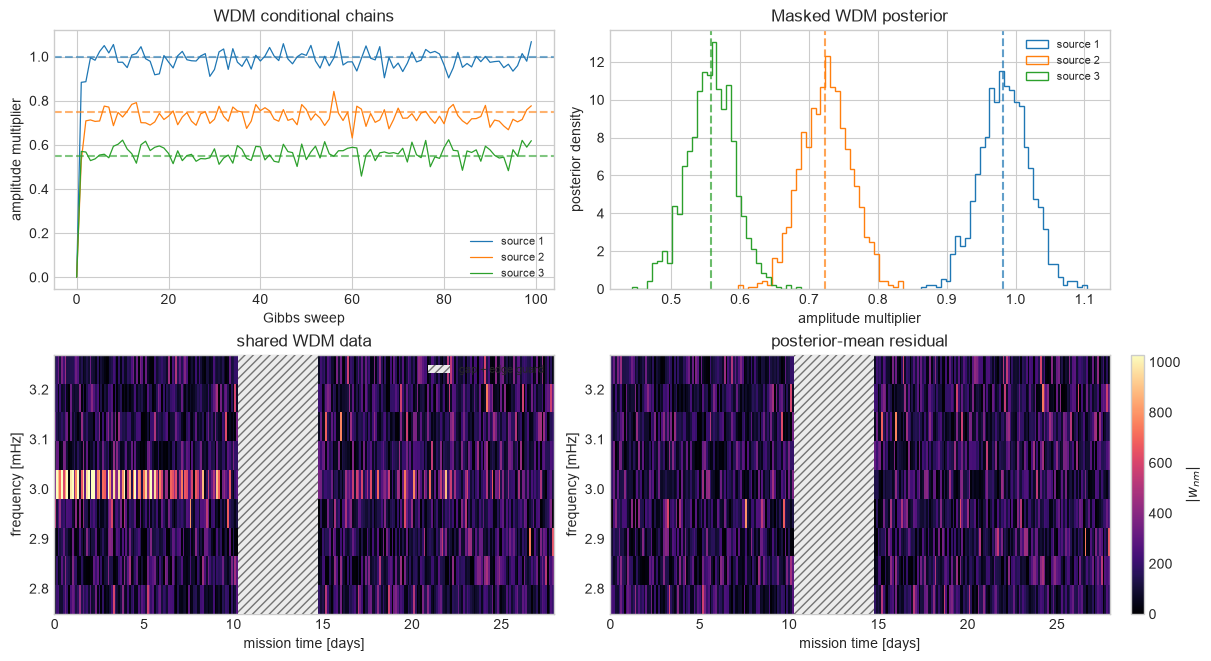

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), layout="constrained")

for source_index in range(3):
    axes[0, 0].plot(
        wdm_gibbs_history[:100, source_index],
        lw=0.9,
        color=f"C{source_index}",
        label=f"source {source_index + 1}",
    )
    axes[0, 0].axhline(
        WDM_GLOBAL_TRUTH[source_index],
        color=f"C{source_index}",
        ls="--",
        alpha=0.6,
    )
    axes[0, 1].hist(
        wdm_gibbs_samples[:, source_index],
        bins=34,
        density=True,
        histtype="step",
        color=f"C{source_index}",
        label=f"source {source_index + 1}",
    )
    axes[0, 1].axvline(
        wdm_global_joint[source_index],
        color=f"C{source_index}",
        ls="--",
        alpha=0.7,
    )
axes[0, 0].set(
    xlabel="Gibbs sweep", ylabel="amplitude multiplier", title="WDM conditional chains"
)
axes[0, 1].set(
    xlabel="amplitude multiplier",
    ylabel="posterior density",
    title="Masked WDM posterior",
)
axes[0, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=8)

wdm_global_show = (wdm_frequency > 2.75e-3) & (wdm_frequency < 3.25e-3)
data_display = np.abs(wdm_global_data[:, wdm_global_show].T)
residual_display = np.abs(wdm_final_residual[:, wdm_global_show].T)
data_display[:, wdm_global_gap_pixels] = np.nan
residual_display[:, wdm_global_gap_pixels] = np.nan
global_colour_scale = np.nanpercentile(data_display, 99.5)

for ax, image_data, title in zip(
    axes[1],
    (data_display, residual_display),
    ("shared WDM data", "posterior-mean residual"),
):
    image = ax.pcolormesh(
        wdm_global_pixel_time,
        1e3 * wdm_frequency[wdm_global_show],
        image_data,
        shading="nearest",
        cmap="magma",
        vmin=0,
        vmax=global_colour_scale,
    )
    mark_gap(
        ax,
        GAP_DAYS[0] - WDM_GLOBAL_GAP_GUARD_DAYS,
        GAP_DAYS[1] + WDM_GLOBAL_GAP_GUARD_DAYS,
        label="gap + edge guard",
    )
    ax.set(xlabel="mission time [days]", ylabel="frequency [mHz]", title=title)
axes[1, 0].legend(fontsize=8, loc="upper right")
fig.colorbar(image, ax=axes[1], label=r"$|w_{nm}|$", pad=0.02)
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-wdm-global-fit.png" alt="expected output: lisa-wdm-global-fit" style="max-width:100%">

</details>

### Animation: the WDM residual handed from block to block

As in Module 06, every frame is one conditional source update rather than one
completed sweep. The parameter-space move is on the left. On the right, the
same shared WDM residual is updated and passed to the next source block. The
hatched gap-plus-guard interval is absent from **every** update; Gibbs sampling
does not invent coefficients inside the missing interval.

In [12]:
wdm_animation_start = 12
wdm_animation_stop = wdm_animation_start + 30
wdm_animation_states = wdm_gibbs_substates[wdm_animation_start:wdm_animation_stop]
wdm_animation_blocks = wdm_gibbs_active_blocks[wdm_animation_start:wdm_animation_stop]
wdm_animation_means = wdm_gibbs_conditional_means[
    wdm_animation_start:wdm_animation_stop
]
wdm_animation_sds = wdm_gibbs_conditional_sds[wdm_animation_start:wdm_animation_stop]
wdm_animation_initial = wdm_gibbs_substates[wdm_animation_start - 1]
wdm_animation_path = np.vstack([wdm_animation_initial, wdm_animation_states])

wdm_covariance_12 = wdm_global_covariance[:2, :2]
wdm_sigma_12 = np.sqrt(np.diag(wdm_covariance_12))
wdm_a1_grid = np.linspace(
    wdm_global_joint[0] - 4 * wdm_sigma_12[0],
    wdm_global_joint[0] + 4 * wdm_sigma_12[0],
    120,
)
wdm_a2_grid = np.linspace(
    wdm_global_joint[1] - 4 * wdm_sigma_12[1],
    wdm_global_joint[1] + 4 * wdm_sigma_12[1],
    120,
)
WDM_A1_GRID, WDM_A2_GRID = np.meshgrid(wdm_a1_grid, wdm_a2_grid)
wdm_offsets_12 = np.stack(
    [WDM_A1_GRID - wdm_global_joint[0], WDM_A2_GRID - wdm_global_joint[1]],
    axis=-1,
)
wdm_mahalanobis_12 = np.einsum(
    "...i,ij,...j->...",
    wdm_offsets_12,
    np.linalg.inv(wdm_covariance_12),
    wdm_offsets_12,
)

fig, (wdm_posterior_ax, wdm_residual_ax) = plt.subplots(1, 2, figsize=(12, 4.5))
wdm_posterior_ax.contour(
    WDM_A1_GRID,
    WDM_A2_GRID,
    np.exp(-0.5 * wdm_mahalanobis_12),
    levels=np.exp(-0.5 * np.array([9.0, 4.0, 1.0])),
    colors=".65",
)
wdm_posterior_ax.plot(
    WDM_GLOBAL_TRUTH[0], WDM_GLOBAL_TRUTH[1], "*", color="k", ms=10, label="injected"
)
wdm_posterior_ax.plot(
    wdm_global_joint[0],
    wdm_global_joint[1],
    "+",
    color="C3",
    ms=10,
    mew=2,
    label="joint mean",
)
(wdm_path_line,) = wdm_posterior_ax.plot([], [], color=".7", lw=1)
(wdm_step_line,) = wdm_posterior_ax.plot([], [], lw=3)
(wdm_point,) = wdm_posterior_ax.plot([], [], "o", color="k", ms=5)
wdm_posterior_ax.set(
    xlabel="source 1 amplitude",
    ylabel="source 2 amplitude",
    title="conditional moves through the WDM posterior",
)
wdm_posterior_ax.legend(fontsize=8)

wdm_initial_animation_residual = wdm_global_data.copy()
wdm_initial_animation_display = np.abs(
    wdm_initial_animation_residual[:, wdm_global_show].T
)
wdm_initial_animation_display[:, wdm_global_gap_pixels] = np.nan
wdm_residual_image = wdm_residual_ax.pcolormesh(
    wdm_global_pixel_time,
    1e3 * wdm_frequency[wdm_global_show],
    wdm_initial_animation_display,
    shading="nearest",
    cmap="magma",
    vmin=0,
    vmax=global_colour_scale,
)
mark_gap(
    wdm_residual_ax,
    GAP_DAYS[0] - WDM_GLOBAL_GAP_GUARD_DAYS,
    GAP_DAYS[1] + WDM_GLOBAL_GAP_GUARD_DAYS,
    label=None,
)
wdm_conditional_text = wdm_residual_ax.text(
    0.02,
    0.95,
    "",
    transform=wdm_residual_ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.88, edgecolor="none"),
)
wdm_residual_ax.set(
    xlabel="mission time [days]", ylabel="frequency [mHz]", title="shared WDM residual"
)


def animate_wdm_gibbs_block(frame):
    state = wdm_animation_states[frame]
    previous = wdm_animation_path[frame]
    active = int(wdm_animation_blocks[frame])
    colour = f"C{active}"
    wdm_path_line.set_data(
        wdm_animation_path[: frame + 2, 0], wdm_animation_path[: frame + 2, 1]
    )
    wdm_step_line.set_data([previous[0], state[0]], [previous[1], state[1]])
    wdm_step_line.set_color(colour)
    wdm_point.set_data([state[0]], [state[1]])

    residual_after = wdm_global_data - np.sum(
        state[:, None, None] * wdm_global_templates, axis=0
    )
    residual_display = np.abs(residual_after[:, wdm_global_show].T)
    residual_display[:, wdm_global_gap_pixels] = np.nan
    wdm_residual_image.set_array(residual_display.ravel())
    wdm_conditional_text.set_text(
        f"draw a{active + 1} from its conditional\n"
        f"mean {wdm_animation_means[frame]:.3f}, "
        f"sd {wdm_animation_sds[frame]:.3f}\n"
        f"new value {state[active]:.3f}"
    )
    wdm_posterior_ax.set_title(f"block {active + 1}: condition on the other sources")
    wdm_residual_ax.set_title(f"pass this residual to block {(active + 1) % 3 + 1}")
    return (
        wdm_path_line,
        wdm_step_line,
        wdm_point,
        wdm_residual_image,
        wdm_conditional_text,
    )


wdm_gibbs_animation = FuncAnimation(
    fig,
    animate_wdm_gibbs_block,
    frames=len(wdm_animation_states),
    interval=320,
)
plt.close(fig)
show_animation(wdm_gibbs_animation)

> **⚠️ What WDM changes—and what it does not**
>
> - The gap is localised, so most WDM pixels remain usable rather than every
> Fourier bin being contaminated by a mission-long window.
> - The likelihood, source blocks, and noise block all use exactly the same mask.
> - Source coupling remains: one-pass subtraction is still order-dependent, and
> an imperfect source model still leaves structure for later blocks to absorb.
> - Masking whole columns discards more than the literal missing samples. Gap-edge
> pixels can remain correlated. The 0.75-day guard is a visible conservative
> teaching choice, not a calibrated production rule, so this diagonal
> likelihood is not a complete gap-marginalised analysis.

### Question

Reverse the one-pass source order and compare its masked residual norm with the forward pass and the joint fit. Why does WDM gap localisation not remove order dependence between overlapping sources?

In [13]:
reverse_order = [2, 1, 0]
# Your code here: repeat the one-pass updates in reverse_order, then compare the
# masked residual norms of the forward pass, the reverse pass, and the joint fit.

<details>
<summary>Hint</summary>

Each source is fitted to a residual containing the current errors from the other sources. WDM localises the gap, not source-model error.

</details>


<!-- colab-badge-next -->
Next: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/10_fast_likelihoods.ipynb)

---

# Worked solutions

Everything above this line is the lab notebook, unchanged. Below are the
solutions to its exercises, as cells that actually run: execute the notebook
from the top and every variable they need will already exist.

## Question: how local is a gap?

In [14]:
missing_sample_fraction = 1.0 - available.mean()
gap_columns = (pixel_time >= GAP_DAYS[0]) & (pixel_time <= GAP_DAYS[1])
print(f"missing time samples:     {missing_sample_fraction:.3f}")
print(f"WDM columns over the gap: {gap_columns.mean():.3f}")

missing time samples:     0.107
WDM columns over the gap: 0.107


The gap is local in time and local in WDM columns, but **not** local in
frequency: convolving with the sharp-edged window spreads its power across
essentially the whole band. That is the entire argument for analysing gapped
data in a time-frequency basis rather than a pure Fourier one — and also the
reason a diagonal WDM likelihood is only an approximation near the edges, where
neighbouring pixels become correlated.

## Question: order dependence, again

In [15]:
reverse_residual = wdm_global_data.copy()
reverse_amplitudes = np.zeros(3)
for source_index in reverse_order:
    template = wdm_global_templates[source_index]
    reverse_amplitudes[source_index] = wdm_global_inner(
        template, reverse_residual
    ) / wdm_global_inner(template, template)
    reverse_residual -= reverse_amplitudes[source_index] * template

joint_residual = wdm_global_data - np.sum(
    wdm_global_joint[:, None, None] * wdm_global_templates, axis=0
)
print(
    "forward one-pass norm:",
    wdm_global_inner(wdm_one_pass_residual, wdm_one_pass_residual),
)
print("reverse one-pass norm:", wdm_global_inner(reverse_residual, reverse_residual))
print("joint-fit norm:       ", wdm_global_inner(joint_residual, joint_residual))

forward one-pass norm: 33882.70041902111
reverse one-pass norm: 33916.17700770403
joint-fit norm:        33855.071721874854


Both one-pass orderings lose to the joint fit, and they lose by different
amounts. Moving to a WDM basis localised the *gap*; it did nothing about
source-model error, because overlapping sources overlap in time-frequency too.
Choosing a better basis and choosing a better estimator are independent
decisions, and you need both.